# 📊 German Coalition Agreements: A Comparative NLP Analysis (2021 vs. 2025)

This notebook compares the 2021 (Scholz Ampel-Koalition) and 2025 (Merz CDU/CSU-SPD Koalition) German Government Coalition Agreements across three stages:
1. **Stage 1 (Exploratory Words & Word Clouds)**: Masked word clouds showing the most frequent meaningful content words (excluding bureaucratic and standard stopwords).
2. **Stage 2 (Policy Dictionary Density Analysis)**: Comparative densities (count per 10k words) across 7 major policy domains, refined to remove false positives and generic terms.
3. **Stage 3 (Collocation/Context Search)**: Analysis of neighboring adjectives and verbs in a 5-token window around critical policy concepts.

## 📦 Setup & Import Dependencies

In [25]:
import os
import json
import PyPDF2
import nltk
from nltk.corpus import stopwords
from nltk.probability import FreqDist
import spacy
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Force loading the installed German package
nlp = spacy.load("de_core_news_sm")
print(f"Loaded SpaCy model: {nlp.meta['name']} v{nlp.meta['version']}")

/opt/anaconda3/lib/python3.12/site-packages/spacy/util.py:910: UserWarning: [W095] Model 'de_core_news_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.2). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


Loaded SpaCy model: core_news_sm v3.8.0


## 🧹 Text Processing & Filtering Functions

In [26]:
def clean_and_lemmatize(text, nlp):
    try:
        stop_words = set(stopwords.words("german"))
    except LookupError:
        nltk.download("stopwords")
        stop_words = set(stopwords.words("german"))
        
    # Strictly filter out bureaucratic/procedural filler words
    custom_stopwords = {
        'sowie', 'müssen', 'insbesondere', 'dazu', 'weiteren', 'weitere',
        'werden', 'können', 'soll', 'sollen', 'unserer', 'unsere', 'mehr', 'ab',
        'dafür', 'dabei', 'deshalb', 'beispiel', 'beim', 'ebene', 'besser',
        'jahr', 'jahren', 'rahmen', 'gelten', 'bereich', 'bereichen', 'weiterhin',
        'wichtig', 'land', 'setzen', 'schaffen', 'stärken', 'unterstützen',
        'fördern', 'ermöglichen', 'verbessern', 'stellen', 'nutzen', 'weiterentwickeln',
        'erhöhen', 'einsetzen', 'entwickeln', 'umsetzen', 'entsprechend', 'deutschland', 'deutsch',
        'bund', 'gemeinsam', 'bestehend', 'international', 'öffentlich', 'national', 'mensch',
        'menschen', 'stark', 'schnell', 'finanziell', 'wirtschaft', 'zusammenarbeit', 'sorgen',
        'ziel', 'ziele', 'maßnahme', 'maßnahmen', 'umsetzung', 'möglichkeit', 'möglichkeiten',
        'bundesregierung', 'aufgabe', 'aufgaben', 'leistung', 'leistungen', 'entwicklung',
        'stärkung', 'reform', 'reformen', 'bereich', 'bereiche', 'rahmen', 'ebene',
        'notwendig', 'zentral', 'wichtig', 'weitere', 'entsprechend', 'bestehend',
        'neu', 'schnell', 'fair', 'sichern', 'erleichtern', 'bleiben', 'schützen',
        'tragen', 'erreichen', 'schaffen', 'bringen', 'fortsetzen', 'schließen'
    }
    
    spacy_stopwords = nlp.Defaults.stop_words
    all_stopwords = stop_words.union(spacy_stopwords).union(custom_stopwords)
    
    doc = nlp(text)
    allowed_pos = {"NOUN", "ADJ", "PROPN"}
    
    lemmas = []
    for token in doc:
        if token.is_alpha and token.pos_ in allowed_pos:
            lemma = token.lemma_.lower()
            if lemma not in all_stopwords and len(lemma) > 3:
                if lemma == "digitalisierung":
                    lemma = "digital"
                lemmas.append(lemma)
    return lemmas

## 📈 Stage 1: Exploratory Words Extraction
Here we read the texts of the two coalition agreement PDFs and compute top content word frequencies.

In [27]:
pdf_2021 = "Koalitionsvertrag_2021-2025.pdf"
pdf_2025 = "Koalitionsvertrag-2025.pdf"

print("Extracting text from 2021 PDF...")
with open(pdf_2021, 'rb') as file:
    reader = PyPDF2.PdfReader(file)
    text_2021 = ''.join([page.extract_text() for page in reader.pages if page.extract_text()])

print("Extracting text from 2025 PDF...")
with open(pdf_2025, 'rb') as file:
    reader = PyPDF2.PdfReader(file)
    text_2025 = ''.join([page.extract_text() for page in reader.pages if page.extract_text()])

print("Running exploratory lemmatization...")
lemmas_2021 = clean_and_lemmatize(text_2021, nlp)
freq_2021 = dict(FreqDist(lemmas_2021).most_common(50))

lemmas_2025 = clean_and_lemmatize(text_2025, nlp)
freq_2025 = dict(FreqDist(lemmas_2025).most_common(50))

print("Top 5 terms 2021:", list(freq_2021.items())[:5])
print("Top 5 terms 2025:", list(freq_2025.items())[:5])

Extracting text from 2021 PDF...
Extracting text from 2025 PDF...
Running exploratory lemmatization...
Top 5 terms 2021: [('europäisch', 162), ('digital', 157), ('arbeit', 60), ('kommune', 58), ('kind', 57)]
Top 5 terms 2025: [('europäisch', 127), ('digital', 124), ('kommune', 66), ('unternehmen', 49), ('förderung', 48)]


## 🎨 Word Cloud Visualizations
Generating exploratory word clouds masked in the shape of Germany.

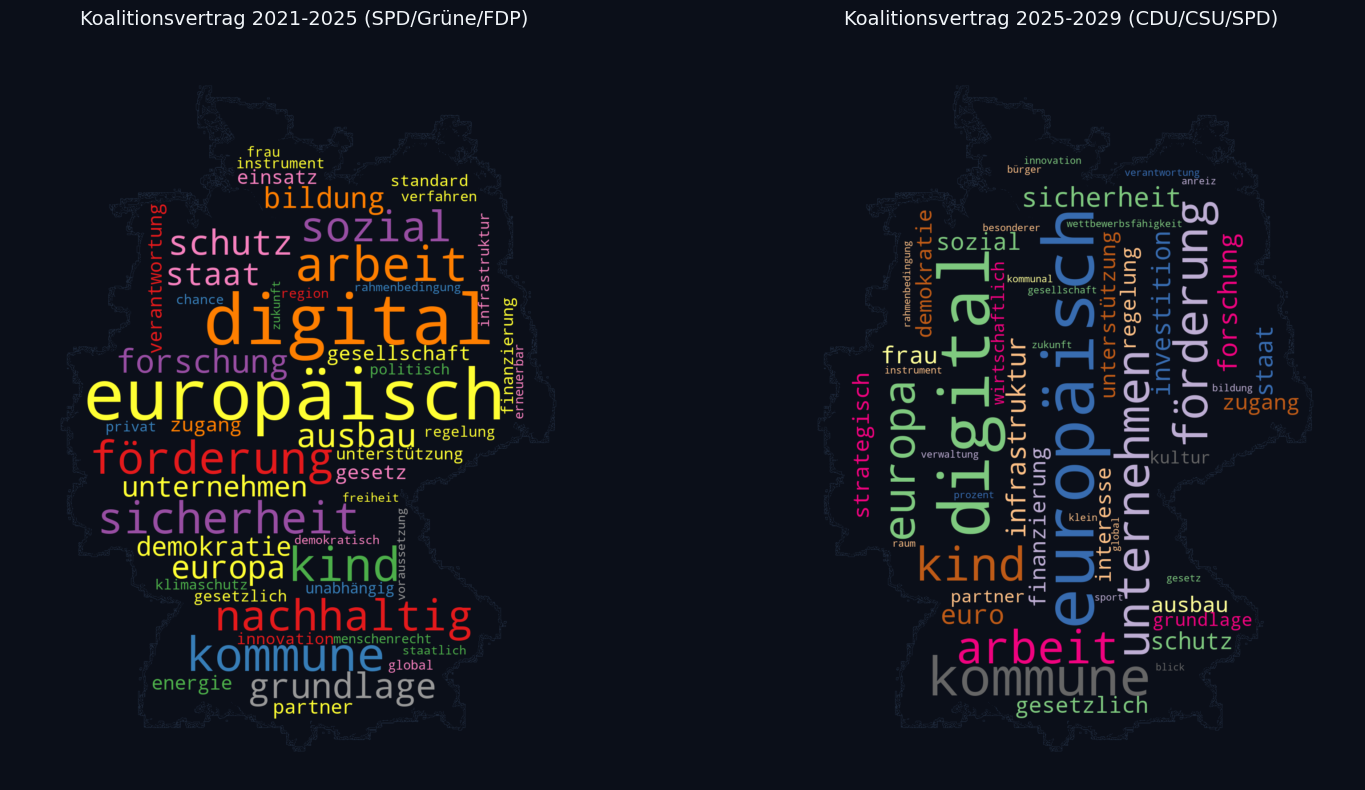

In [28]:
# Create Word Clouds with Germany mask
mask_image = np.array(Image.open("g.png"))

wc_2021 = WordCloud(width=800, height=800, background_color="#0b0f19", colormap="Set1", mask=mask_image, contour_width=1, contour_color="#1e293b").generate_from_frequencies(freq_2021)
wc_2025 = WordCloud(width=800, height=800, background_color="#0b0f19", colormap="Accent", mask=mask_image, contour_width=1, contour_color="#1e293b").generate_from_frequencies(freq_2025)

# Plot Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor("#0b0f19")

axes[0].imshow(wc_2021, interpolation="bilinear")
axes[0].set_title("Koalitionsvertrag 2021-2025 (SPD/Grüne/FDP)", color="#f1f5f9", fontsize=14, pad=15)
axes[0].axis("off")

axes[1].imshow(wc_2025, interpolation="bilinear")
axes[1].set_title("Koalitionsvertrag 2025-2029 (CDU/CSU/SPD)", color="#f1f5f9", fontsize=14, pad=15)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 📊 Stage 2: Policy Dictionary Analysis
We evaluate the relative density of words associated with seven core political themes, using the refined dictionary stems.

In [29]:
with open("policy_dictionary.json", "r", encoding="utf-8") as f:
    dictionary = json.load(f)

def run_dictionary_analysis(text, dictionary):
    text_lower = text.lower()
    total_words = len(text_lower.split())
    results = {}
    
    for concept, keywords in dictionary.items():
        count = 0
        matches = {}
        for kw in keywords:
            kw_count = text_lower.count(kw)
            if kw_count > 0:
                matches[kw] = kw_count
                count += kw_count
                
        density = (count / total_words) * 10000 if total_words > 0 else 0
        results[concept] = {
            "count": count,
            "density": round(density, 2),
            "matches": matches
        }
    return results

dict_results_2021 = run_dictionary_analysis(text_2021, dictionary)
dict_results_2025 = run_dictionary_analysis(text_2025, dictionary)

print("Completed dictionary density analysis for both agreements!")
print("Migration control density 2021 vs 2025:", dict_results_2021['migration_control']['density'], "vs", dict_results_2025['migration_control']['density'])

Completed dictionary density analysis for both agreements!
Migration control density 2021 vs 2025: 2.98 vs 6.09


## 📊 Stage 2: Policy Dictionary Visualizations
Plotting the density values of political concepts in both coalitions.

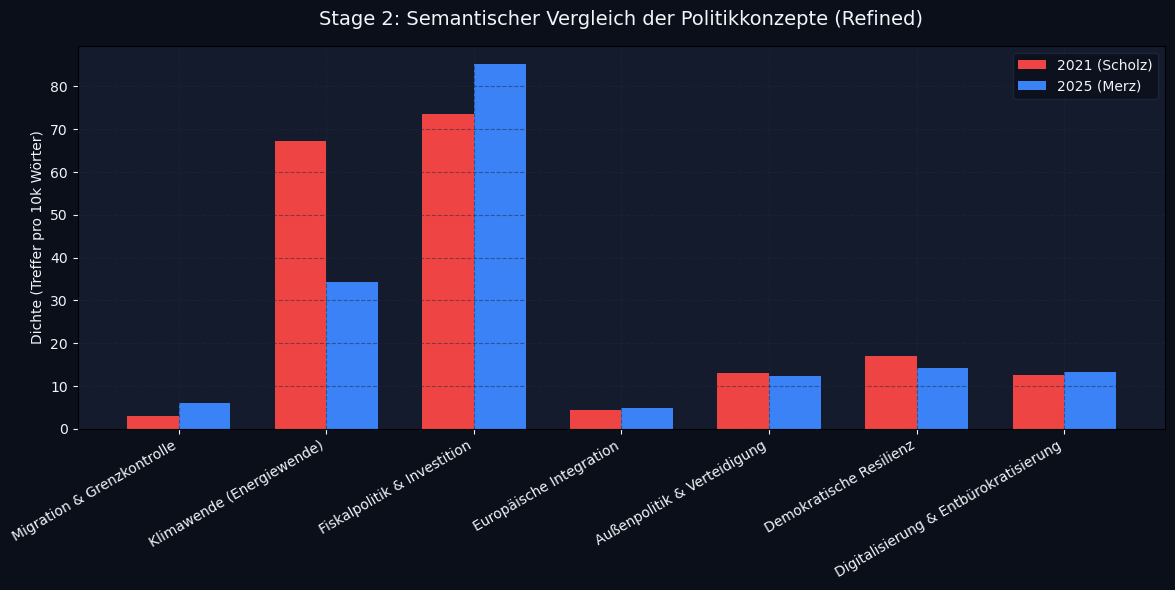

In [30]:
conceptLabels = {
  "migration_control": "Migration & Grenzkontrolle",
  "climate_transition": "Klimawende (Energiewende)",
  "fiscal_policy": "Fiskalpolitik & Investition",
  "eu_integration": "Europäische Integration",
  "foreign_policy": "Außenpolitik & Verteidigung",
  "democratic_resilience": "Demokratische Resilienz",
  "digitalization_debureaucratization": "Digitalisierung & Entbürokratisierung"
}

concepts = list(conceptLabels.values())
keys = list(conceptLabels.keys())

densities_2021 = [dict_results_2021[k]["density"] for k in keys]
densities_2025 = [dict_results_2025[k]["density"] for k in keys]

x = np.arange(len(keys))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0b0f19")
ax.set_facecolor("#141b2d")

rects1 = ax.bar(x - width/2, densities_2021, width, label='2021 (Scholz)', color="#ef4444")
rects2 = ax.bar(x + width/2, densities_2025, width, label='2025 (Merz)', color="#3b82f6")

ax.set_ylabel('Dichte (Treffer pro 10k Wörter)', color="#f1f5f9")
ax.set_title('Stage 2: Semantischer Vergleich der Politikkonzepte (Refined)', color="#f1f5f9", fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(concepts, rotation=30, ha="right", color="#f1f5f9")
ax.tick_params(colors="#f1f5f9")
ax.legend(facecolor="#0b0f19", edgecolor="#1e293b", labelcolor="#f1f5f9")
ax.grid(color="#1e293b", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 🔍 Stage 3: Semantic Context / Collocation Search
We analyze the surrounding words (adjectives and verbs within a 5-token window) of target policy concepts, filtering out filler words.

In [31]:
def run_context_search(text, nlp, target_categories, window_size=5):
    doc = nlp(text)
    collocations = {cat: {} for cat in target_categories}
    allowed_pos = {"ADJ", "VERB"}
    
    try:
        german_stop = set(stopwords.words("german"))
    except LookupError:
        nltk.download("stopwords")
        german_stop = set(stopwords.words("german"))
        
    # Generic filler verbs and adjectives that do not convey policy direction
    blacklist = {
        "müssen", "können", "sollen", "werden", "wollen", "haben", "geben", "stehen", "setzen", "bringen", "gehen", "sehen", "lassen", "kommen", "nehmen",
        "schaffen", "stärken", "fördern", "verbessern", "einsetzen", "umsetzen", "unterstützen", "sichern", "ausbauen", "erhöhen", "verringern", "anpassen",
        "fortführen", "weiterentwickeln", "fortsetzen", "regeln", "legen", "führen", "betreffen", "gehören", "gelten", "bleiben", "stellen", "liegen", "machen",
        "halten", "sein", "zusätzlich", "neu", "gut", "wichtig", "notwendig", "groß", "klein", "hoch", "niedrig", "stark", "schnell", "direkt", "indirekt",
        "gemeinsam", "einzeln", "verschieden", "allgemein", "breit", "eng", "klar", "deutlich", "weit", "nah", "möglich", "entsprechend", "beispielhaft",
        "insbesondere", "deutsch", "europäisch", "international", "national", "regional", "lokal", "kommunal", "global", "staatlich", "öffentlich",
        "deutschland", "sowie", "dabei", "dazu", "dafür"
    }
    custom_stops = german_stop.union(blacklist)
    
    for i, token in enumerate(doc):
        lemma = token.lemma_.lower()
        matched_cat = None
        for cat, checker in target_categories.items():
            if checker(lemma):
                matched_cat = cat
                break
        if matched_cat:
            start = max(0, i - window_size)
            end = min(len(doc), i + window_size + 1)
            
            for j in range(start, end):
                if j == i:
                    continue
                neighbor = doc[j]
                neighbor_lemma = neighbor.lemma_.lower()
                if neighbor.pos_ in allowed_pos and neighbor.is_alpha and neighbor_lemma not in custom_stops and len(neighbor_lemma) > 2:
                    collocations[matched_cat][neighbor_lemma] = collocations[matched_cat].get(neighbor_lemma, 0) + 1
                    
    formatted_results = {}
    for cat, neighbors in collocations.items():
        sorted_neighbors = sorted(neighbors.items(), key=lambda x: x[1], reverse=True)[:5]
        formatted_results[cat] = [{"word": n[0], "count": n[1]} for n in sorted_neighbors]
    return formatted_results

target_categories = {
    "migration_enforcement": lambda l: ("grenz" in l or "abschieb" in l or "rückführ" in l or "zurückweis" in l or "ausreise" in l) and not ("begrenz" in l or "wertgrenz" in l or "preisgrenz" in l or "altersgrenz" in l or "bagatellgrenz" in l or "minijobgrenz" in l or "grenzwert" in l or "kappungsgrenz" in l or "zuverdienstgrenze" in l),
    "klimaschutz": lambda l: "klima" in l or "energiewende" in l or "erneuerbar" in l,
    "investitionen": lambda l: "invest" in l or "schuldenbremse" in l,
    "digitalisierung": lambda l: "digital" in l or "bürokratieabbau" in l or "entbürokratisierung" in l or "bürokratierückbau" in l
}

colloc_results_2021 = run_context_search(text_2021, nlp, target_categories)
colloc_results_2025 = run_context_search(text_2025, nlp, target_categories)

readable_colloc_labels = {
    "migration_enforcement": "MIGRATION & GRENZKONTROLLE",
    "klimaschutz": "KLIMAWENDE & UMWELTSCHUTZ",
    "investitionen": "INVESTITION & FISKALPOLITIK",
    "digitalisierung": "DIGITALISIERUNG & BÜROKRATIE"
}

for key, label in readable_colloc_labels.items():
    print(f"=== Kontext-Vergleich für '{label}' ===")
    print(f"{'2021 (Scholz)':<30} | {'2025 (Merz)':<30}")
    print("-" * 65)
    c2021 = colloc_results_2021.get(key, [])
    c2025 = colloc_results_2025.get(key, [])
    for idx in range(5):
        w21 = f"{c2021[idx]['word']} ({c2021[idx]['count']})" if idx < len(c2021) else ""
        w25 = f"{c2025[idx]['word']} ({c2025[idx]['count']})" if idx < len(c2025) else ""
        print(f"{w21:<30} | {w25:<30}")
    print()

=== Kontext-Vergleich für 'MIGRATION & GRENZKONTROLLE' ===
2021 (Scholz)                  | 2025 (Merz)                   
-----------------------------------------------------------------
wirksam (3)                    | ehrenamtlich (2)              
offensive (2)                  | vorübergehend (2)             
konsequent (2)                 | beantragen (2)                
freiwillig (2)                 | dauerhaft (2)                 
finden (1)                     | freiwillig (2)                

=== Kontext-Vergleich für 'KLIMAWENDE & UMWELTSCHUTZ' ===
2021 (Scholz)                  | 2025 (Merz)                   
-----------------------------------------------------------------
massiv (6)                     | verfolgen (3)                 
nachhaltig (4)                 | erreichen (2)                 
zentral (3)                    | pariser (2)                   
beschleunigen (3)              | wirtschaftlich (2)            
brauchen (3)                   | beschleunigt 

## 📤 Export Structured Data for Dashboard
Exporting Stage 1, 2, and 3 data structured for web consumption.

In [32]:
structured_data = {
    "exploratory": {
        "2021": [{"word": word, "count": count} for word, count in freq_2021.items()],
        "2025": [{"word": word, "count": count} for word, count in freq_2025.items()]
    },
    "dictionary": {
        "2021": dict_results_2021,
        "2025": dict_results_2025
    },
    "collocations": {
        "2021": colloc_results_2021,
        "2025": colloc_results_2025
    }
}

output_path = "coalition_words_data.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(structured_data, f, ensure_ascii=False, indent=2)
print(f"Data successfully exported to {output_path}!")

Data successfully exported to coalition_words_data.json!
